In [2]:
COUNTRIES = {
    'Belgium': [(2000, 2012), (2014, 2024)],
    'Germany': [(2000, 2012), (2014, 2024)], #very low data coverage
    'Italy': [(2000, 2012), (2014, 2024)],
    'Portugal': [None, (2014, 2024)], #no data for first period
    'Spain':[(2000, 2012), (2014, 2024)],
    'Sweden': [(2000, 2012), (2014, 2024)]

}

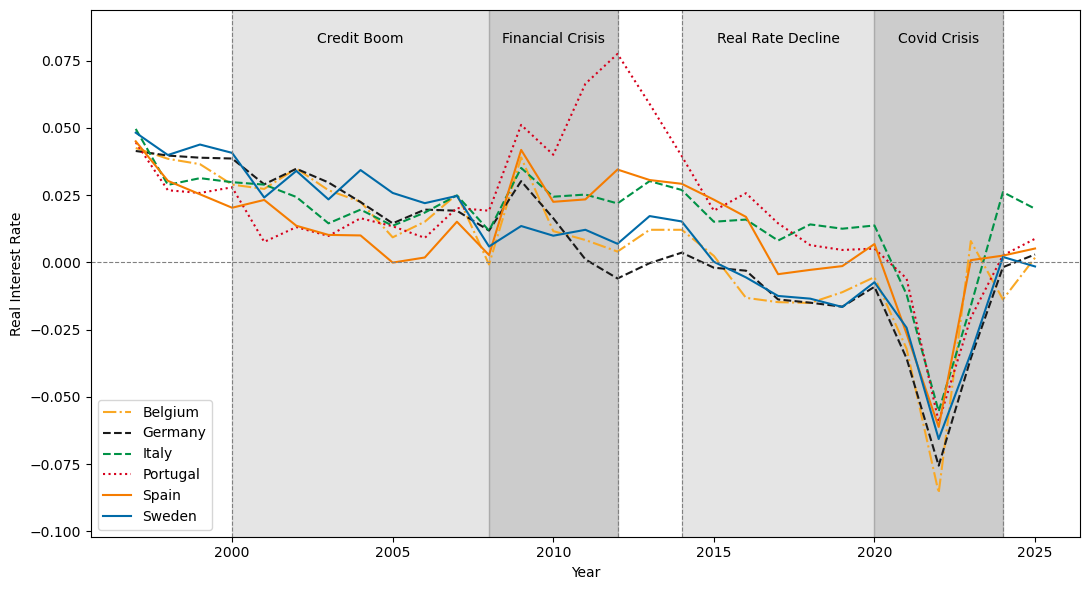

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from modules.RealRate import RealRate
from CompareCountries import COUNTRY_STYLES

df = pd.DataFrame()
for country in COUNTRIES.keys():
    rr = RealRate(country)
    df = pd.concat([df, rr.df], axis=0, ignore_index=True)



fig, ax = plt.subplots(figsize=(11, 6))

for country, g in df.groupby('country'):
    color = COUNTRY_STYLES.get(country)['color']
    linestyle = COUNTRY_STYLES.get(country)['linestyle']
    ax.plot(g['year'], g['realinterestrate'], color=color, label=country, linestyle=linestyle)

ax.axvline(2000, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2012, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2014, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2024, color='grey', linewidth=0.8, linestyle='--')

ax.axvspan(2000, 2008, color='gray', alpha=0.2)
ax.text((2000 + 2008) / 2, ax.get_ylim()[1], 'Credit Boom', ha='center', va='top')

ax.axvspan(2008, 2012, color='gray', alpha=0.4)
ax.text((2008 + 2012) / 2, ax.get_ylim()[1], 'Financial Crisis', ha='center', va='top')

ax.axvspan(2014, 2020, color='gray', alpha=0.2)
ax.text((2014 + 2020) / 2, ax.get_ylim()[1], 'Real Rate Decline', ha='center', va='top')

ax.axvspan(2020, 2024, color='gray', alpha=0.4)
ax.text((2020 + 2024) / 2, ax.get_ylim()[1], 'Covid Crisis', ha='center', va='top')


ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Real Interest Rate')
ax.legend()
ax.margins(x=0.05, y=0.1)  
fig.tight_layout()
plt.show()


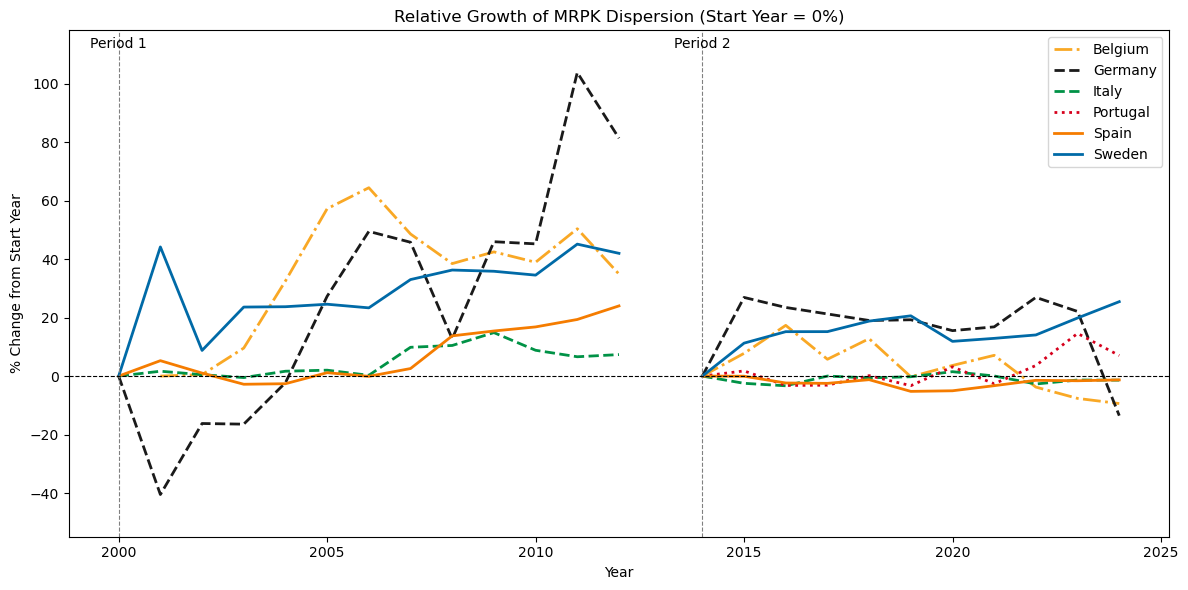

,Country,Time,Revenue Data Coverage %,Change Real Interest Rate %,Increase in Real Interest Rate %,Decrease in Real Interest Rate %,Change log MRPK %,Increase in MRPK %,Decrease in MRPK %,Coef log_a on capital growth,P-Value Coefficient
0,Belgium,2000 - 2012,14.64,-2.49,6.34,-8.83,35.60,64.83,-29.23,0.080,0.091
1,Belgium,2014 - 2024,18.27,-2.59,10.32,-12.91,-6.94,30.56,-37.50,0.046,0.127
2,Germany,2000 - 2012,0.85,-4.46,2.93,-7.39,97.83,175.25,-77.42,0.007,0.900
3,Germany,2014 - 2024,1.91,-0.54,8.12,-8.66,-5.59,36.85,-42.44,0.056,0.005
4,Italy,2000 - 2012,11.54,-0.79,4.05,-4.84,7.83,19.00,-11.17,-1.279,0.000
5,Italy,2014 - 2024,27.18,-0.08,8.95,-9.03,-1.23,6.97,-8.20,0.017,0.159
6,Portugal,2014 - 2024,17.27,-3.69,6.89,-10.58,8.37,28.92,-20.55,0.051,0.000
7,Spain,2000 - 2012,33.31,1.42,6.92,-5.50,22.60,31.64,-9.04,0.038,0.000
8,Spain,2014 - 2024,44.00,-2.67,7.49,-10.16,-1.15,5.54,-6.69,0.048,0.000
9,Sweden,2000 - 2012,4.69,-3.38,3.33,-6.71,47.76,76.76,-29.00,0.082,0.028


In [ ]:
from CompareCountries import CompareCountries
from MisallocationAnalysis import MisallocationAnalysis

allanalises = []

for country, rangelist in COUNTRIES.items():
    for range in rangelist:
        if range == None:
            continue
        analysis = MisallocationAnalysis(country, range[0], range[1], sector='C')
        allanalises.append(analysis)



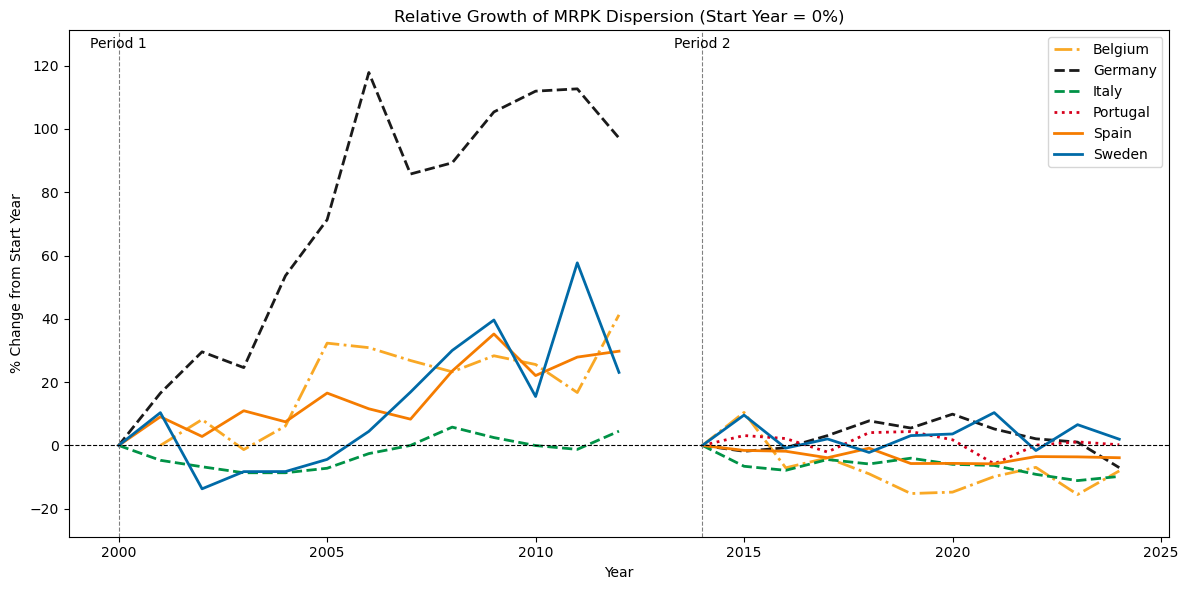

,Country,Time,Revenue Data Coverage %,Change Real Interest Rate %,Increase in Real Interest Rate %,Decrease in Real Interest Rate %,Change log MRPK %,Increase in MRPK %,Decrease in MRPK %,Coef log_a on capital growth,P-Value Coefficient
0,Belgium,2000 - 2012,31.64,-2.49,6.34,-8.83,40.58,65.56,-24.98,0.080,0.091
1,Belgium,2014 - 2024,32.91,-2.59,10.32,-12.91,-4.97,32.17,-37.14,0.046,0.127
2,Germany,2000 - 2012,5.46,-4.46,2.93,-7.39,77.74,103.62,-25.88,0.007,0.900
3,Germany,2014 - 2024,5.91,-0.54,8.12,-8.66,-6.50,13.68,-20.18,0.056,0.005
4,Italy,2000 - 2012,25.85,-0.79,4.05,-4.84,5.15,20.81,-15.66,-1.279,0.000
5,Italy,2014 - 2024,42.00,-0.08,8.95,-9.03,-9.87,7.13,-17.00,0.017,0.159
6,Portugal,2014 - 2024,37.64,-3.69,6.89,-10.58,1.06,17.00,-15.94,0.051,0.000
7,Spain,2000 - 2012,48.85,1.42,6.92,-5.50,29.39,55.17,-25.78,0.038,0.000
8,Spain,2014 - 2024,57.91,-2.67,7.49,-10.16,-3.72,5.63,-9.35,0.048,0.000
9,Sweden,2000 - 2012,9.92,-3.38,3.33,-6.71,36.19,97.25,-61.06,0.082,0.028


In [4]:

comparison = CompareCountries(allanalises)
countriesmrpkplot = comparison.plot_compare_mrpk(sample='full')
comparison.compare(sample='full')

